In [173]:
import os
import pandas as pd

data = []
path = "."

for category in os.listdir(path):
    category_path = os.path.join(path, category)
    if not os.path.isdir(category_path):
        continue
    for file in os.listdir(category_path):
        file_path = os.path.join(category_path, file)
        if file.endswith(".txt"):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
                data.append({"category": category, "text": text})

In [174]:
df = pd.DataFrame(data)
print("Empty text:", df["text"].str.strip().eq("").sum())
print("Duplicate text:", df.duplicated(subset=["text"]).sum())
print("Missing category:", df["category"].isna().sum())

Empty text: 0
Duplicate text: 98
Missing category: 0


Số lượng báo

In [175]:
print("Total samples:", len(df))
label_counts = df['category'].value_counts()
print(label_counts)

Total samples: 2225
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [176]:
# percent of imbalance
print(label_counts / len(df) * 100)

category
sport            22.966292
business         22.921348
politics         18.741573
tech             18.022472
entertainment    17.348315
Name: count, dtype: float64


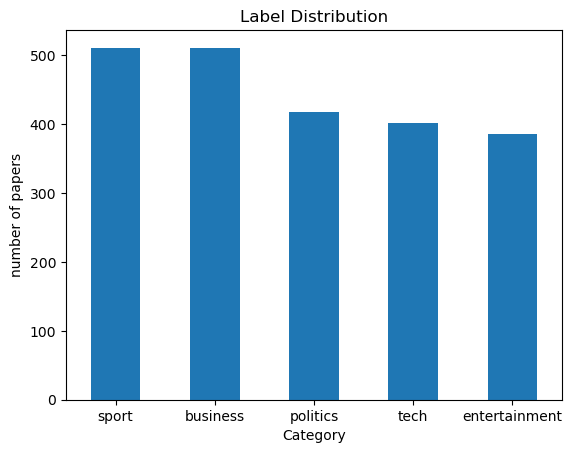

In [177]:
import matplotlib.pyplot as plt
label_counts.plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Category")
plt.ylabel("number of papers")
plt.xticks(rotation=360) 
plt.show()

Tổng quan dữ liệu: 
- Kích thuớc: 2225 văn bản, phân loại vào 5 chủ đề
- Độ cân bằng: Tương đối cân bằng:
    + Nhóm Sport & business dẫn đầu, vào khoảng 23%
    + Nhóm Entertainment chiếm tỉ trọng thấp nhất nhưng cũng rơi vào khoảng 17.3%
=> Khoảng gap không quá lớn trên từng loại dữ liệu, chênh lệch tối đa khoảng 6%

In [178]:
# số lượng từ mỗi bài
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print(df['word_count'].describe())

count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64


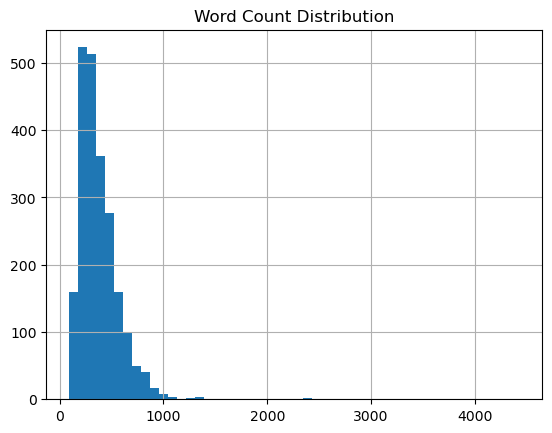

In [179]:
df['word_count'].hist(bins=50)
plt.title("Word Count Distribution")
plt.show()

- Trung bình mỗi bài viết dài khoảng 384 từ. Tuy nhiên, độ lệch chuẩn rất lớn (238 từ) cho thấy sự dao động mạnh về dung lượng giữa các bài.  
- Phân phối độ lệch: Phân phối dữ liệu bị lệch phải rõ rệt. Phần lớn dữ liệu tập trung ở vùng 100 - 600 từ, nhưng xuất hiện các giá trị ngoại lệ cực lớn, với bài viết dài nhất lên tới 4432 từ.  
- Tuy nhiên dữ liệu thô khá sạch, khi bài viết ngắn nhất có 89 từ, biểu thị rõ không có file rỗng hoặc chỉ chứa tiêu đề.
=> Cần huớng xử lý ngoại lệ, nên thiết lập độ dài tối đa ở mức khoảng 800 từ khi chuẩn hóa dữ liệu đầu vào, giúp tối ưu hóa việc làm

In [180]:
#word count by category
print(df.groupby('category')['word_count'].mean())

category
business         328.880392
entertainment    330.621762
politics         453.973621
sport            329.262231
tech             502.695761
Name: word_count, dtype: float64


- Nhóm nội dung chuyên sâu: Các bài viết thuộc chủ đề tech và politics có dung lượng lớn nhất, đạt trung bình lần lượt là 502 từ và 453 từ mỗi bài.  
- Nhóm nội dung tiêu chuẩn: Các chủ đề business, sport, và entertainment có độ dài trung bình gần như tương đương nhau.

## LOẠI BỎ Stopwords, punctuation, thực hiện stemming/lemmatization

In [181]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Tải các gói dữ liệu ngôn ngữ cần thiết của nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/luongnhatkhoi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [182]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_lemmatize(text):
    # step 1: lowercasing
    text = str(text).lower()
     # step 2: remove puncation 
    text = re.sub(r'([.,!?])(?=[^\s])', r'\1 ', text) # dùng để tạo khoảng trắng sau dấu câu
    text = re.sub(r'[^\w\s]','',text)
    words = text.split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(clean_words)


In [183]:
df['clean_text'] = df['text'].apply(clean_and_lemmatize)
df['clean_word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print("Before preprocessing: \\n ",df['text'].iloc[0][:500])
print("After preprocessing: \\n ",df['clean_text'].iloc[0][:500])
print("Describe",df['clean_word_count'].describe())

Before preprocessing: \n  Musicians to tackle US red tape

Musicians' groups are to tackle US visa regulations which are blamed for hindering British acts' chances of succeeding across the Atlantic.

A singer hoping to perform in the US can expect to pay $1,300 (£680) simply for obtaining a visa. Groups including the Musicians' Union are calling for an end to the "raw deal" faced by British performers. US acts are not faced with comparable expense and bureaucracy when visiting the UK for promotional purposes.

Nigel McCu
After preprocessing: \n  musician tackle u red tape musician group tackle u visa regulation blamed hindering british act chance succeeding across atlantic singer hoping perform u expect pay 1 300 680 simply obtaining visa group including musician union calling end raw deal faced british performer u act faced comparable expense bureaucracy visiting uk promotional purpose nigel mccune musician union said british musician disadvantaged compared u counterpart sponsor make 

In [184]:
label_mapping = {
    label: idx
    for idx, label in enumerate(sorted(df["category"].unique()))
}

df["label_id"] = df["category"].map(label_mapping)


In [185]:
import json

with open("label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)


In [186]:
df.to_csv("bbc_clean.csv", index=False, encoding="utf-8")

## Vectorization (TF-IDF)

In [187]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
data_tfidf = tfidf.fit_transform(df['clean_text'])
print("Kiểu dữ liệu sinh ra:", type(data_tfidf))
print("Kích thước Ma trận:", data_tfidf.shape)
print(f"Số lượng bài báo: {data_tfidf.shape[0]}")
print(f"Số lượng từ vựng (features): {data_tfidf.shape[1]}")
feature_names = tfidf.get_feature_names_out()
print("\nMột số từ vựng đại diện:", feature_names[1000:1010])

Kiểu dữ liệu sinh ra: <class 'scipy.sparse._csr.csr_matrix'>
Kích thước Ma trận: (2225, 5000)
Số lượng bài báo: 2225
Số lượng từ vựng (features): 5000

Một số từ vựng đại diện: ['command' 'comment' 'commentator' 'commerce' 'commercial' 'commission'
 'commissioned' 'commissioner' 'commit' 'commitment']


## Dummy Model Training from TF-IDF Matrix

In [188]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    data_tfidf,
    df["label_id"],
    test_size=0.2,
    stratify=df["label_id"],
    random_state=42
)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print("Train matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Train matrix shape: (1780, 5000)
Test matrix shape: (445, 5000)
Accuracy: 0.982


In [189]:
target_names = [label for label, _ in sorted(label_mapping.items(), key=lambda x: x[1])]

print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Confusion matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification report:

               precision    recall  f1-score   support

     business       0.96      0.97      0.97       102
entertainment       0.99      0.99      0.99        77
     politics       0.99      0.98      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.97      0.97      0.97        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445

Confusion matrix:

[[ 99   1   1   0   1]
 [  0  76   0   0   1]
 [  2   0  82   0   0]
 [  0   0   0 102   0]
 [  2   0   0   0  78]]


**Note:** Kết quả trên chỉ là train thử nhanh từ ma trận TF-IDF dummy `max_features=5000`. Vì `data_tfidf` được `fit_transform` trên toàn bộ dataset trước khi split, phần này phù hợp để demo baseline nhưng chưa phải pipeline đánh giá cuối cùng cho Model Team.

# Train Test Split

In [190]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42
)


In [191]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)


# Config for TF-IDF

In [192]:
TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    norm="l2"
)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [193]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    norm="l2"
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_val = tfidf.transform(val_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])


In [194]:
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

Number of TF-IDF features: 54513
X_train shape: (1557, 54513)
X_val shape: (334, 54513)
X_test shape: (334, 54513)


In [195]:
tfidf_config = {
    "ngram_range": [1, 2],
    "min_df": 2,
    "max_df": 0.85,
    "sublinear_tf": True,
    "norm": "l2",
    "fit_on": "train only"
}
with open("tfidf_config.json", "w") as f:
    json.dump(tfidf_config, f, indent=2)


## Clean Pipeline Model Training

Phần này train model trên pipeline sạch: split data trước, fit TF-IDF trên train only, sau đó transform validation/test để tránh data leakage.

In [196]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

y_train = train_df["label_id"]
y_val = val_df["label_id"]
y_test = test_df["label_id"]

models = {
    "Dummy majority baseline": DummyClassifier(strategy="most_frequent"),
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(random_state=42),
}

results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    results.append({
        "model": model_name,
        "val_accuracy": accuracy_score(y_val, val_pred),
        "val_macro_f1": f1_score(y_val, val_pred, average="macro"),
        "val_weighted_f1": f1_score(y_val, val_pred, average="weighted"),
    })
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
results_df


,model,val_accuracy,val_macro_f1,val_weighted_f1
3,LinearSVC,0.988024,0.988090,0.988023
2,LogisticRegression,0.985030,0.985030,0.985060
1,MultinomialNB,0.979042,0.978845,0.979118
0,Dummy majority baseline,0.227545,0.074146,0.084358


In [197]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
test_pred = best_model.predict(X_test)

target_names = [label for label, _ in sorted(label_mapping.items(), key=lambda item: item[1])]

print("Best model:", best_model_name)
print("Test accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Test macro F1:", round(f1_score(y_test, test_pred, average="macro"), 4))
print("\nClassification report:\n")
print(classification_report(y_test, test_pred, target_names=target_names))
print("Confusion matrix:\n")
print(confusion_matrix(y_test, test_pred))


Best model: LinearSVC
Test accuracy: 0.982
Test macro F1: 0.9816

Classification report:

               precision    recall  f1-score   support

     business       0.99      0.96      0.97        77
entertainment       0.98      0.98      0.98        58
     politics       0.95      0.98      0.97        62
        sport       1.00      1.00      1.00        77
         tech       0.98      0.98      0.98        60

     accuracy                           0.98       334
    macro avg       0.98      0.98      0.98       334
 weighted avg       0.98      0.98      0.98       334

Confusion matrix:

[[74  1  1  0  1]
 [ 0 57  1  0  0]
 [ 1  0 61  0  0]
 [ 0  0  0 77  0]
 [ 0  0  1  0 59]]


Kết quả ở phần này mới nên dùng làm baseline chính thức, vì vectorizer không nhìn thấy validation/test trong lúc fit vocabulary và IDF.

## KFold vs StratifiedKFold Cross Validation

Với bài BBC News Classification, chọn `StratifiedKFold` vì đây là bài toán phân loại nhiều lớp và ta muốn mỗi fold giữ tỷ lệ class gần giống dataset gốc. `KFold` phù hợp hơn cho regression hoặc khi label distribution không phải vấn đề.

In [198]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

X_text = df["clean_text"]
y = df["label_id"]

tfidf_params = {
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.85,
    "sublinear_tf": True,
    "norm": "l2",
}

cv_models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(random_state=42),
}

stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for model_name, model in cv_models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("model", model),
    ])
    scores = cross_validate(
        pipeline,
        X_text,
        y,
        cv=stratified_cv,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1,
    )
    cv_results.append({
        "model": model_name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
        "cv_macro_f1_std": scores["test_f1_macro"].std(),
        "cv_weighted_f1_mean": scores["test_f1_weighted"].mean(),
        "cv_weighted_f1_std": scores["test_f1_weighted"].std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean", ascending=False)
cv_results_df


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_weighted_f1_mean,cv_weighted_f1_std
2,LinearSVC,0.982921,0.003363,0.982805,0.003677,0.982942,0.003375
1,LogisticRegression,0.979775,0.002462,0.979455,0.002564,0.979817,0.002427
0,MultinomialNB,0.964494,0.005928,0.963399,0.006152,0.964426,0.005947


In [199]:
# Optional sanity check: KFold can be compared with StratifiedKFold, but StratifiedKFold is preferred here.
kfold_cv = KFold(n_splits=5, shuffle=True, random_state=42)

kfold_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("model", LinearSVC(random_state=42)),
])

kfold_scores = cross_validate(
    kfold_pipeline,
    X_text,
    y,
    cv=kfold_cv,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1,
)

print("KFold LinearSVC accuracy mean:", round(kfold_scores["test_accuracy"].mean(), 4))
print("KFold LinearSVC macro F1 mean:", round(kfold_scores["test_f1_macro"].mean(), 4))

KFold LinearSVC accuracy mean: 0.9856
KFold LinearSVC macro F1 mean: 0.9853


Kết luận: dùng `StratifiedKFold` cho báo cáo chính vì dataset là classification nhiều lớp. Cross-validation giúp đánh giá model ổn định hơn một lần split train/validation/test duy nhất.

## Overfitting / High Bias Diagnostics

Các biểu đồ dưới đây giúp kiểm tra model có bị overfit hoặc high bias không. Nếu train score cao nhưng validation score thấp, đó là dấu hiệu overfitting. Nếu cả hai cùng thấp, đó là dấu hiệu high bias/underfitting.

/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
5 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/anaconda3/envs/ml_workspace/lib/python3.14/site-pac

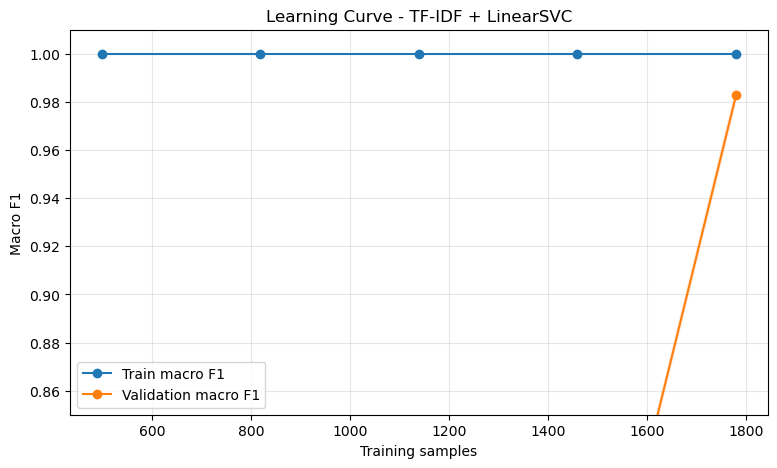

Final train macro F1: 1.0
Final validation macro F1: 0.9828
Final train-validation gap: 0.0172
Diagnosis: no strong overfitting/high-bias signal


In [200]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("model", LinearSVC(random_state=42)),
])

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline,
    X_text,
    y,
    cv=stratified_cv,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train macro F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.plot(train_sizes, val_mean, marker="o", label="Validation macro F1")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
plt.title("Learning Curve - TF-IDF + LinearSVC")
plt.xlabel("Training samples")
plt.ylabel("Macro F1")
plt.ylim(0.85, 1.01)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

gap = train_mean[-1] - val_mean[-1]
print("Final train macro F1:", round(train_mean[-1], 4))
print("Final validation macro F1:", round(val_mean[-1], 4))
print("Final train-validation gap:", round(gap, 4))

if val_mean[-1] < 0.80 and train_mean[-1] < 0.85:
    print("Diagnosis: possible high bias / underfitting")
elif gap > 0.05:
    print("Diagnosis: possible overfitting")
else:
    print("Diagnosis: no strong overfitting/high-bias signal")


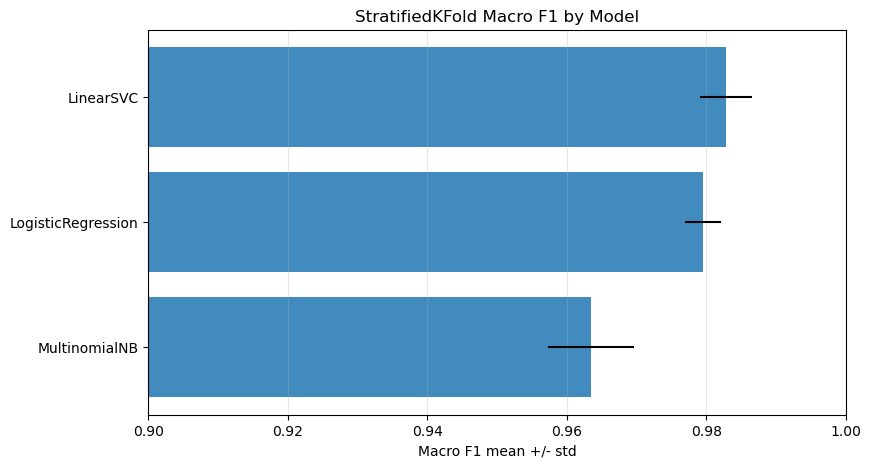

,model,cv_macro_f1_mean,cv_macro_f1_std,cv_accuracy_mean,cv_accuracy_std
2,LinearSVC,0.982805,0.003677,0.982921,0.003363
1,LogisticRegression,0.979455,0.002564,0.979775,0.002462
0,MultinomialNB,0.963399,0.006152,0.964494,0.005928


In [201]:
plot_df = cv_results_df.copy()
plot_df = plot_df.sort_values("cv_macro_f1_mean", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["cv_macro_f1_mean"], xerr=plot_df["cv_macro_f1_std"], alpha=0.85)
plt.title("StratifiedKFold Macro F1 by Model")
plt.xlabel("Macro F1 mean +/- std")
plt.xlim(0.90, 1.0)
plt.grid(axis="x", alpha=0.3)
plt.show()

cv_results_df[["model", "cv_macro_f1_mean", "cv_macro_f1_std", "cv_accuracy_mean", "cv_accuracy_std"]]


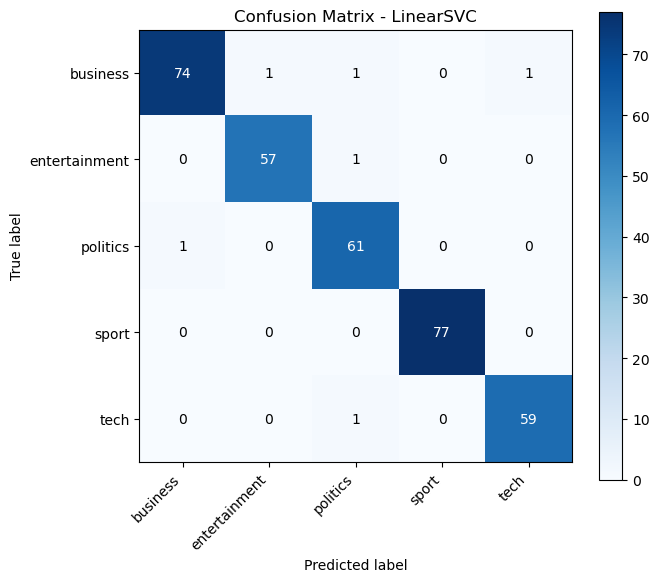

In [202]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > threshold else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()
